(01-04-markowitz)=

# Markowitz, Roy en Tobin

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1952–1959.

**Wat we al weten.** Uit [](#01-03-williams-ddm) komt een theorie van het
*niveau* van een prijs: de contante waarde van de dividenden, verdisconteerd
tegen een voet $r$. De replicatie daar liet zien dat schommelingen in $r$ meer van
de prijsbeweging verklaren dan de dividenden. Williams had geen theorie van $r$, en hij bekeek elk
aandeel apart.

**Welke vraag staat open.** Wat is het risico van een belegging: de schommeling
van dat ene stuk papier, of wat het toevoegt aan de portefeuille die de belegger
al heeft?
```

## Overzicht

Welke portefeuille hoort een belegger te houden, en hoe riskant is één activum
daarin? Het antwoord van Markowitz: een activum is zo riskant als zijn
covariantie met de portefeuille, en de beste portefeuilles volgen exact uit de
verwachte rendementen $\boldsymbol{\mu}$ en de covariantiematrix
$\boldsymbol{\Sigma}$. Maar $\boldsymbol{\mu}$ is zo slecht te schatten dat de
geschatte optimale portefeuille in de praktijk verliest van gewoon gelijk spreiden,
en nog duidelijker van de minimum-variantieportefeuille, die $\boldsymbol{\mu}$
niet gebruikt.

In deze lecture:

- leiden we de efficiënte rand af: alle efficiënte portefeuilles zijn mengsels
  van twee fondsen;

- voegen we met Tobin een risicovrij activum toe, waarna iedereen dezelfde
  tangentportefeuille houdt;

- laten we zien waarom in een grote portefeuille alleen covariantie overblijft;

- simuleren we hoeveel van de optimale Sharpe-ratio overblijft als
  $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$ geschat moeten worden;

- repliceren we {cite:t}`DeMiguelGarlappiUppal2009` op French-data: de
  gelijkgewogen portefeuille (hierna 1/N) verslaat de mean-variance-portefeuille
  (de tangentportefeuille uit geschatte momenten).

Markowitz publiceerde zijn artikel in maart 1952
{cite}`Markowitz1952`. Het stond haaks op Williams: als alleen verwachte
dividenden tellen, stopt een belegger alles in één aandeel, en dat doet niemand.
In juli kwam A. D. Roy in *Econometrica*
bij bijna dezelfde meetkunde uit {cite}`Roy1952`. Tobin voegde in 1958 het
risicovrije activum toe {cite}`Tobin1958`, en in 1959 volgde het boek van
Markowitz {cite}`Markowitz1959`. Dit werk verplaatste de vraag: van wat een aandeel waard is naar welke
portefeuille een belegger wil houden. Op de vraag theorie of feit (is dit een
theorie die getoetst wordt, of een feit dat op een verklaring wacht?) is het
antwoord: een *theorie van keuze*, geen uitspraak over prijzen. Die komt pas in
[het CAPM](#02-08-capm).

## Intuïtie: waarom zou dit waar zijn?

Neem een belegger met één aandeel die een tweede overweegt. Vóór 1952 luidde de
vraag: hoe riskant is dat tweede aandeel? Markowitz vroeg: hoe riskant wordt de
portefeuille?

Denk aan twee aandelen die even hard op en neer gaan, maar nooit tegelijk. Elk
apart is riskant. Half om half is de portefeuille veel rustiger, want waar de
een verliest, wint de ander vaak. Denk nu aan twee aandelen die even hard
bewegen en dat altijd tegelijk doen. Samen zijn ze even riskant als elk apart.

Wie alleen de afzonderlijke aandelen bekijkt, ziet tussen die twee gevallen geen
verschil. Het verschil zit in hoe ze samen bewegen: *diversificatie is het
beheer van covariantie*. Honderd bankaandelen die op elkaar lijken, zijn niet
gespreid. Drie activa die niets met elkaar te maken hebben, zijn dat wel.

In een goed gespreide portefeuille hangt het risico van een extra aandeel dus
alleen af van zijn covariantie met wat er al is. Zijn *idiosyncratische risico*
(het eigen risico, dat met de rest niets te maken heeft) verdwijnt in de massa.
Voor risico dat verdwijnt, hoeft niemand betaald te worden.

Met verwacht rendement en variantie als twee grootheden ontstaat een afruil. De
portefeuilles die niet te verslaan zijn, vormen de *efficient frontier*
(efficiënte rand: de laagste variantie bij elk verwacht rendement). Roys belegger
wil vooral een ramp vermijden en komt bij dezelfde portefeuilles uit.

Tobin voegde schatkistpapier toe. Dan kiest een belegger eerst het risicovolle
mandje met de beste verhouding tussen premie en risico, en daarna pas hoeveel
geld erin gaat. Wie voorzichtig is, houdt meer schatkistpapier, wie durft, leent
bij. Het mandje is voor beiden hetzelfde.

De intuïtie doet dus twee voorspellingen. Een mengsel van activa kan veiliger
zijn dan het veiligste activum, omdat de delen niet samen bewegen. En een
activum dat met de rest meebeweegt, krijgt weinig gewicht, ook als het veel
oplevert.

## Toy-voorbeeld: de minimum-variantieportefeuille van drie activa

Het kleinste voorbeeld heeft drie activa met jaarcijfers: aandelen, kleine
aandelen en obligaties. We volgen met de hand één
mechanisme: een mengsel van riskante activa kan veiliger zijn dan het veiligste
activum. De eerste cel laadt de pakketten voor de hele lecture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.**

| Activum | $\mu_i$ | $\sigma_i$ | $\Corr$ met aandelen | $\Corr$ met kleine aandelen | $\Corr$ met obligaties |
|---|---|---|---|---|---|
| aandelen | 10,0% | 20,0% | 1 | 1/3 | 0 |
| kleine aandelen | 14,0% | 30,0% | 1/3 | 1 | 0 |
| obligaties | 4,0% | 10,0% | 0 | 0 | 1 |

Obligaties zijn het veiligst, en de twee soorten aandelen bewegen deels samen. De rendementen zijn
netto: 10% is 0,10.

**Het recept.** De *minimum-variantieportefeuille* (de portefeuille met de
laagste variantie) heeft gewichten evenredig met $\boldsymbol{\Sigma}^{-1}\mathbf{1}$:
de inverse covariantiematrix maal een vector van enen, daarna geschaald zodat de
gewichten optellen tot één. De theorie leidt dit recept als eerste af.

**Stap 1: de covariantiematrix.** Elke covariantie is
$\Sigma_{ij} = \rho_{ij}\sigma_i\sigma_j$, dus is de covariantie tussen
aandelen en kleine aandelen $(1/3)(0{,}20)(0{,}30) = 0{,}02$:

$$
\boldsymbol{\mu} =
\begin{pmatrix} 0{,}10 \\ 0{,}14 \\ 0{,}04 \end{pmatrix},
\qquad
\boldsymbol{\Sigma} =
\begin{pmatrix}
0{,}04 & 0{,}02 & 0 \\
0{,}02 & 0{,}09 & 0 \\
0 & 0 & 0{,}01
\end{pmatrix}.
$$

**Stap 2: de inverse.** Obligaties correleren met niets, dus $\boldsymbol{\Sigma}$
valt uiteen in een $2\times2$-blok en een getal. Het blok heeft determinant
$0{,}04 \cdot 0{,}09 - 0{,}02^2 = 0{,}0032$. De inverse van een
$2\times2$-matrix ontstaat door de diagonaal te wisselen, het teken van de
andere twee om te draaien en alles door de determinant te delen. Zo is
$0{,}09/0{,}0032 = 28{,}125$ en $-0{,}02/0{,}0032 = -6{,}25$. Voor obligaties is het
$1/0{,}01 = 100$:

$$
\boldsymbol{\Sigma}^{-1} =
\begin{pmatrix}
28{,}125 & -6{,}25 & 0 \\
-6{,}25 & 12{,}5 & 0 \\
0 & 0 & 100
\end{pmatrix}.
$$

Het negatieve getal buiten de diagonaal zegt: hoe meer aandelen in de
portefeuille, hoe minder kleine aandelen er nodig zijn. Twee activa die samen bewegen, vervangen elkaar.

**Stap 3: de rijsommen.** $\boldsymbol{\Sigma}^{-1}\mathbf{1} = (21{,}875;\;
6{,}25;\; 100)'$, met som $128{,}125$.

**Stap 4: de gewichten.** Delen door die som geeft
$\mathbf{w}_{\mathrm{mv}} = (7/41;\; 2/41;\; 32/41)' = (0{,}1707;\; 0{,}0488;\;
0{,}7805)'$.

**Stap 5: het risico.** Elke rij van $\boldsymbol{\Sigma}\mathbf{w}_{\mathrm{mv}}$
is de covariantie van een activum met de portefeuille, en die is voor alle drie
gelijk: $(0{,}04 \cdot 7 + 0{,}02 \cdot 2)/41 = (0{,}02 \cdot 7 + 0{,}09 \cdot 2)/41
= 0{,}01 \cdot 32/41 = 0{,}32/41$. Omdat de gewichten optellen tot één, is
$\sigma^2_{\mathrm{mv}} = \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w} = 0{,}32/41 =
0{,}0078$, dus $\sigma_{\mathrm{mv}} = 8{,}83\%$.

Obligaties alleen hebben 10,0% standaarddeviatie. Het mengsel met 22% in
aandelen heeft 8,83%. De codecel rekent dezelfde getallen na.

In [2]:
mu = np.array([0.10, 0.14, 0.04])
sd = np.array([0.20, 0.30, 0.10])
corr = np.array([[1.0, 1 / 3, 0.0],
                 [1 / 3, 1.0, 0.0],
                 [0.0, 0.0, 1.0]])
Sigma = corr * np.outer(sd, sd)
ones = np.ones(3)

Sinv_1 = np.linalg.solve(Sigma, ones)        # Sigma^{-1} 1, stap 3
w_mv = Sinv_1 / Sinv_1.sum()                 # stap 4
sigma_mv = np.sqrt(w_mv @ Sigma @ w_mv)      # stap 5

pd.DataFrame(
    {"met de hand": [0.1707, 0.0488, 0.7805, 0.0883],
     "code": [w_mv[0], w_mv[1], w_mv[2], sigma_mv]},
    index=["gewicht aandelen", "gewicht kleine aandelen", "gewicht obligaties",
           "standaarddeviatie"],
).round(4)

,met de hand,code
gewicht aandelen,0.1707,0.1707
gewicht kleine aandelen,0.0488,0.0488
gewicht obligaties,0.7805,0.7805
standaarddeviatie,0.0883,0.0883


De twee kolommen zijn gelijk. Riskante aandelen toevoegen maakt het geheel
rustiger dan obligaties alleen, omdat ze niet met obligaties meebewegen.

## Theorie

We beginnen bij de eerste-ordevoorwaarde, met als eerste gevolg
het recept uit het toy-voorbeeld. Daaruit volgt de kern: de efficiënte rand is
een parabool, en elke portefeuille erop is een mengsel van twee vaste fondsen.
Daarna voegen we een risicovrij activum toe (Tobin, met Roy als variant), laten
we zien waarom in een grote portefeuille alleen covariantie overblijft, en
waarom de theorie in de praktijk strandt op de schatting van $\boldsymbol{\mu}$.

### Opzet en aannames

We werken met netto rendementen, in de notatie van [](#00-00-setup): $r$ is
netto (10% is 0,10), $R = 1 + r$ bruto, en de risicovrije rente $R^{f}$ netto
(2% is 0,02). Er zijn $N$ risicovolle activa met rendementen
$\mathbf{r}_{t+1}$, verwachting $\boldsymbol{\mu} = \E[\mathbf{r}_{t+1}]$ en
covariantiematrix $\boldsymbol{\Sigma} = \Var(\mathbf{r}_{t+1})$. Een portefeuille is een gewichtsvector
$\mathbf{w}$ met $\mathbf{w}'\mathbf{1} = 1$, met

$$
\mu_p = \mathbf{w}'\boldsymbol{\mu}, \qquad
\sigma_p^2 = \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
= \sum_{i}\sum_{j} w_i w_j \Cov(r_i, r_j).
$$

De variantie van de portefeuille is een gewogen som van alle covarianties, met
de varianties als het geval $i = j$. Risico betekent in deze lecture
standaarddeviatie. De aannames:

1. **Alleen $\mu_p$ en $\sigma_p^2$ tellen.** Een belegger wil meer verwachting
   en minder variantie, en geeft om niets anders.

2. **$\boldsymbol{\Sigma}$ is positief definiet.** Geen activum is een exacte
   combinatie van de andere, dus $\boldsymbol{\Sigma}^{-1}$ bestaat.

3. **Short verkopen mag.** Gewichten mogen negatief zijn, zodat de
   optimalisatie geen ongelijkheden kent.

4. **Lenen en uitlenen tegen $R^{f}$ mag onbeperkt.** Deze aanname is pas nodig
   vanaf Tobin.

Aanname 1 is de zwakste. Ze geldt bij normaal verdeelde rendementen of
kwadratisch nut, en anders als tweede-ordebenadering van elk nut. Die benadering
volstaat zolang de verdeling niet te scheef is en geen dikke staarten heeft.

### Het kernresultaat: de efficiënte rand

De bewering: elke belegger die aanname 1 volgt, kiest een portefeuille op één
vaste rand, en elke portefeuille op die rand is een mengsel van twee vaste
fondsen.

*Waarom zou dit waar zijn?* Een belegger die een portefeuille ziet met hetzelfde
verwachte rendement en minder variantie, ruilt om. Bij elke ruil daalt zijn
variantie en blijft zijn verwachte rendement gelijk. Hij stopt pas als zo'n ruil
niet meer bestaat, dus op de rand. Alleen welk punt van de rand hij kiest, hangt
van zijn smaak af.

Het probleem is

```{math}
:label: eq-markowitz-probleem
\min_{\mathbf{w}} \ \tfrac12\,\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
\quad\text{onder}\quad
\mathbf{w}'\boldsymbol{\mu} = \mu_p,
\quad \mathbf{w}'\mathbf{1} = 1 .
```

In woorden: zoek de gewichten met de kleinste variantie, onder de eis dat het
verwachte rendement $\mu_p$ is en de gewichten optellen tot één. De factor
$\tfrac12$ houdt de afgeleide schoon. Omdat short verkopen mag (aanname 3), is
een Lagrangiaan genoeg:

$$
\mathcal{L} = \tfrac12\,\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
- \lambda\left(\mathbf{w}'\boldsymbol{\mu} - \mu_p\right)
- \delta\left(\mathbf{w}'\mathbf{1} - 1\right).
$$

Hier is $\lambda$ de schaduwprijs van de rendementseis en $\delta$ die van de
budgeteis; deze $\lambda$ is een Lagrange-multiplicator, niet de prijs van risico
$\lambda_f$ uit de notatie van de reeks. De eerste-ordevoorwaarde is
$\boldsymbol{\Sigma}\mathbf{w} - \lambda\boldsymbol{\mu} - \delta\mathbf{1} = 0$.
Omdat $\boldsymbol{\Sigma}$ inverteerbaar is (aanname 2), volgt

```{math}
:label: eq-markowitz-foc
\mathbf{w} = \boldsymbol{\Sigma}^{-1}
\left(\lambda\boldsymbol{\mu} + \delta\mathbf{1}\right).
```

In woorden: de $i$-de rij van $\boldsymbol{\Sigma}\mathbf{w}$ is
$\Cov(r_i, r_p)$, en in het optimum is die covariantie een vaste lineaire
functie van het verwachte rendement, $\lambda\mu_i + \delta$. De eigen variantie
van activum $i$ telt alleen mee via die covariantie. Stijgt het verwachte
rendement van één activum, dan krijgt het meer gewicht, tot zijn covariantie met
de portefeuille weer in verhouding is. Daalt het, dan omgekeerd.

Het eerste gevolg is het recept uit het toy-voorbeeld. Zonder rendementseis is
$\lambda = 0$, en [](#eq-markowitz-foc) geeft na normaliseren
$\mathbf{w}_{\mathrm{mv}} = \boldsymbol{\Sigma}^{-1}\mathbf{1}/
\mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1}$. Er staat geen $\boldsymbol{\mu}$
in, en op dat feit draait de tweede helft van deze lecture. In het toy-voorbeeld
is deze portefeuille met 8,83% veiliger dan het veiligste activum (10%), zoals
de eerste voorspelling van de intuïtie zei.

Om de rand te tekenen, moeten $\lambda$ en $\delta$ voor elk vereist rendement
$\mu_p$ vastliggen. Daarvoor zijn vier getallen nodig:

```{math}
:label: eq-markowitz-abcd
A = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1},\quad
B = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu},\quad
C = \boldsymbol{\mu}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu},\quad
D = AC - B^2 .
```

In woorden: $A$, $B$ en $C$ zijn de drie manieren om $\mathbf{1}$ en
$\boldsymbol{\mu}$ met $\boldsymbol{\Sigma}^{-1}$ te combineren. $D$ meet hoe
sterk de verwachte rendementen uiteenlopen. Hadden alle activa hetzelfde
verwachte rendement, dan was $D$ nul. In het toy-voorbeeld is $A = 128{,}125$,
de som uit stap 3. $D$ ligt altijd tussen nul en $AC$, want $B^2 \le AC$; hier
is $D = 15{,}625$ tegen $AC = 65{,}5$, bijna een kwart van het maximum.

Invullen van [](#eq-markowitz-foc) in de twee restricties geeft het stelsel
$\lambda B + \delta A = 1$ en $\lambda C + \delta B = \mu_p$. Met de regel van
Cramer volgt

$$
\lambda = \frac{A\mu_p - B}{D},
\qquad
\delta = \frac{C - B\mu_p}{D} .
$$

In woorden: hoe hoger het vereiste rendement, hoe zwaarder de richting
$\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}$ weegt en hoe lichter de richting
$\boldsymbol{\Sigma}^{-1}\mathbf{1}$ van de minimum-variantieportefeuille. In het
toy-voorbeeld wijst die laatste vooral naar obligaties, $(21{,}875;\; 6{,}25;\;
100)'$, en de eerste relatief meer naar aandelen, $(1{,}94;\; 1{,}13;\; 4)'$. Bij
$\mu_p = 10\%$ is $\lambda = (12{,}8125 - 7{,}0625)/15{,}625 = 0{,}368$ en
$\delta = (0{,}51125 - 0{,}70625)/15{,}625 = -0{,}0125$.

De variantie van de oplossing volgt nu snel. Uit [](#eq-markowitz-foc) is
$\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
= \mathbf{w}'(\lambda\boldsymbol{\mu} + \delta\mathbf{1})
= \lambda\mu_p + \delta$ (in het toy-voorbeeld bij 10%: $0{,}0368 - 0{,}0125 =
0{,}0243$), dus

```{math}
:label: eq-markowitz-frontier
\sigma^2(\mu_p) = \frac{A\mu_p^2 - 2B\mu_p + C}{D} .
```

In woorden: de laagste haalbare variantie is een parabool in het vereiste
verwachte rendement, met het minimum bij $\mu_p = B/A$ en variantie $1/A$. In het
toy-voorbeeld is dat 5,51% bij 8,83% standaarddeviatie: de portefeuille die we
met de hand vonden. Wie meer eist, betaalt met variantie. Bij
$\mu_p = 10\%$ geeft de formule $\sigma = 15{,}6\%$, terwijl aandelen alleen
hetzelfde verwachte rendement met 20% risico levert. De codecel rekent deze
getallen na.

In [3]:
Sinv_mu = np.linalg.solve(Sigma, mu)
A = ones @ Sinv_1
B = ones @ Sinv_mu
C = mu @ Sinv_mu
D = A * C - B**2
sigma_at_10 = np.sqrt((A * 0.10**2 - 2 * B * 0.10 + C) / D)   # eq-markowitz-frontier

pd.DataFrame(
    {"met de hand": [128.125, 7.0625, 0.51125, 15.625, 0.0551, 0.0883, 0.1559],
     "code": [A, B, C, D, B / A, np.sqrt(1 / A), sigma_at_10]},
    index=["A", "B", "C", "D", "verwacht rendement minimum-variantie",
           "standaarddeviatie minimum-variantie", "standaarddeviatie op de rand bij 10%"],
).round(4)

,met de hand,code
A,128.1250,128.1250
B,7.0625,7.0625
C,0.5112,0.5112
D,15.6250,15.6250
verwacht rendement minimum-variantie,0.0551,0.0551
standaarddeviatie minimum-variantie,0.0883,0.0883
standaarddeviatie op de rand bij 10%,0.1559,0.1559


De code bevestigt de handberekening. De efficiënte portefeuille met 10%
verwacht rendement heeft ruim een vijfde minder risico dan aandelen alleen.

*Waarom zou de volgende stelling waar zijn?* Denk aan een fondsaanbieder met
klanten die verschillende rendementen eisen. Een klant die een procentpunt meer
eist, krijgt minder obligaties en meer aandelen, en elk volgend procentpunt
vraagt dezelfde verschuiving. Een klant met een eis tussen die van twee andere
klanten krijgt dus een mengsel van hun portefeuilles. Twee fondsen volstaan dan
voor iedereen.

:::{prf:theorem} Twee-fondsenstelling
:label: thm-markowitz-tweefonds

Laat $\mathbf{w}(\mu_p)$ de oplossing van [](#eq-markowitz-probleem) zijn. Dan
geldt voor elk tweetal $\mu_1 \neq \mu_2$ en elke $\alpha \in \mathbb{R}$

$$
\mathbf{w}\!\left(\alpha\mu_1 + (1-\alpha)\mu_2\right)
= \alpha\,\mathbf{w}(\mu_1) + (1-\alpha)\,\mathbf{w}(\mu_2).
$$

In woorden: de portefeuilles op de rand zijn precies de mengsels van twee
willekeurige, van elkaar verschillende portefeuilles op die rand.
:::

Het bewijsidee: vul $\lambda$ en $\delta$ in [](#eq-markowitz-foc) in. De
gewichten worden een vaste vector plus $\mu_p$ maal een tweede vaste vector, een
*affiene* functie van $\mu_p$ (lineair plus een constante). Een mengsel van twee
punten op zo'n rechte ligt weer op die rechte. Welke twee randportefeuilles
als fondsen dienen, maakt niet uit. Een handig paar is de
minimum-variantieportefeuille $\boldsymbol{\Sigma}^{-1}\mathbf{1}/A$ en
$\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}/B$, met verwacht rendement
$C/B = 7{,}24\%$. In het toy-voorbeeld zijn dat $(0{,}171;\; 0{,}049;\; 0{,}780)'$
en $(1{,}9375;\; 1{,}125;\; 4)'/7{,}0625 = (0{,}274;\; 0{,}159;\; 0{,}566)'$.

:::{prf:proof}
:class: dropdown

*Stap 1: de gewichten zijn affien in $\mu_p$.* Vul $\lambda$ en $\delta$ in
[](#eq-markowitz-foc) in:

$$
\mathbf{w}(\mu_p)
= \underbrace{\frac{C\,\boldsymbol{\Sigma}^{-1}\mathbf{1}
- B\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}}{D}}_{\displaystyle \mathbf{g}}
+ \mu_p \underbrace{\frac{A\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}
- B\,\boldsymbol{\Sigma}^{-1}\mathbf{1}}{D}}_{\displaystyle \mathbf{h}} ,
$$

met $\mathbf{g}$ en $\mathbf{h}$ onafhankelijk van $\mu_p$. Dan is
$\mathbf{w}(\alpha\mu_1 + (1-\alpha)\mu_2)
= \mathbf{g} + (\alpha\mu_1 + (1-\alpha)\mu_2)\mathbf{h}
= \alpha(\mathbf{g} + \mu_1\mathbf{h}) + (1-\alpha)(\mathbf{g} + \mu_2\mathbf{h})$,
omdat $\alpha + (1-\alpha) = 1$. Dat is de bewering.

*Stap 2: elk mengsel ligt op de rand.* Het mengsel
$\alpha\mathbf{w}(\mu_1) + (1-\alpha)\mathbf{w}(\mu_2)$ telt op tot één en heeft
verwacht rendement $\alpha\mu_1 + (1-\alpha)\mu_2$. Volgens stap 1 is het gelijk
aan de minimaliserende portefeuille bij dat rendement. Die is uniek omdat
$\boldsymbol{\Sigma}$ positief definiet is (aanname 2). $\square$
:::

Zien alle beleggers dezelfde $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$
(*homogene verwachtingen*, een aanname die Markowitz niet nodig heeft), dan houdt
ook de markt als geheel een mengsel van dezelfde twee fondsen. Dat is de eerste
stap naar een evenwichtsmodel.

### Een risicovrij activum: Tobin en Roy

De bewering: met een risicovrij activum houdt iedereen dezelfde risicovolle
portefeuille, en alleen de dosis verschilt.

*Waarom zou dit waar zijn?* Een belegger verdeelt zijn geld over schatkistpapier,
dat zeker $R^{f}$ oplevert, en een risicovolle portefeuille $p$. Zet hij meer
geld in $p$, dan stijgen premie en standaarddeviatie in dezelfde
verhouding. Ruilt hij $p$ in voor een portefeuille met meer premie per eenheid
risico, dan krijgt hij bij elk risico meer rendement. Hij blijft ruilen tot er
geen betere $p$ meer is. Dat eindpunt hangt af van $R^{f}$, $\boldsymbol{\mu}$
en $\boldsymbol{\Sigma}$, niet van zijn smaak.

Schrijf $\boldsymbol{\mu}^{e} = \boldsymbol{\mu} - R^{f}\mathbf{1}$ voor de
*premies* (verwachte overrendementen boven de risicovrije rente). De belegger
maximeert de *Sharpe-ratio*, de premie per eenheid standaarddeviatie. Sharpe
gebruikte die maat in 1966 {cite}`Sharpe1966`, en later kreeg ze zijn naam.

```{math}
:label: eq-markowitz-sharpe
S(\mathbf{w}) = \frac{\mathbf{w}'\boldsymbol{\mu}^{e}}
{\sqrt{\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}}} .
```

In woorden: de premie per eenheid risico, onafhankelijk van de schaal van
$\mathbf{w}$. De afgeleide gelijk aan nul
stellen geeft $\boldsymbol{\Sigma}\mathbf{w} \propto \boldsymbol{\mu}^{e}$: de
covariantie van elk activum met de portefeuille is evenredig met zijn premie.
Omdat $\boldsymbol{\Sigma}$ inverteerbaar is (aanname 2), volgt na normaliseren

```{math}
:label: eq-markowitz-tangent
\mathbf{w}_{\mathrm{tan}}
= \frac{\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}}
{\mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}}
= \frac{\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} - R^{f}\mathbf{1})}{B - R^{f}A},
\qquad
S_{\max}^2 = (\boldsymbol{\mu}^{e})'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}
= C - 2R^{f}B + (R^{f})^2 A .
```

In woorden: de *tangentportefeuille* weegt elk activum met zijn premie,
gecorrigeerd voor hoe het met de andere activa meebeweegt. $S_{\max}$ is de
helling van de *kapitaalmarktlijn* (de rechte vanuit de risicovrije rente door
de tangentportefeuille), de hoogste Sharpe-ratio die deze activa samen halen.

In het toy-voorbeeld, met een risicovrije rente van 2%, gaat dat met de hand:

- $\boldsymbol{\mu}^{e} = (0{,}08;\; 0{,}12;\; 0{,}02)'$, dus de Sharpe-ratio's
  per activum zijn $0{,}08/0{,}20 = 0{,}40$, $0{,}12/0{,}30 = 0{,}40$ en
  $0{,}02/0{,}10 = 0{,}20$.
- $\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e} = (28{,}125 \cdot 0{,}08 - 6{,}25
  \cdot 0{,}12;\; -6{,}25 \cdot 0{,}08 + 12{,}5 \cdot 0{,}12;\; 100 \cdot 0{,}02)'
  = (1{,}5;\; 1{,}0;\; 2{,}0)'$.
- De som is $4{,}5$, dus $\mathbf{w}_{\mathrm{tan}} = (1/3;\; 2/9;\; 4/9)'$.
- $S_{\max}^2 = 0{,}08 \cdot 1{,}5 + 0{,}12 \cdot 1{,}0 + 0{,}02 \cdot 2{,}0 = 0{,}28$,
  dus $S_{\max} = 0{,}529$.
- Het verwachte rendement is $8{,}22\%$, een premie van $6{,}22$ procentpunt, en
  $\sigma_{\mathrm{tan}} = 0{,}0622/0{,}529 = 11{,}76\%$.

Het mengsel haalt 0,529, meer dan de 0,40 van het beste afzonderlijke activum.
Kleine aandelen hebben het hoogste verwachte rendement en krijgen toch maar 22%,
minder dan de saaie obligaties. Dat komt doordat ze met aandelen meebewegen en
weinig toevoegen aan wat aandelen al leveren. Zo lost de theorie de tweede voorspelling van de intuïtie
in.

Stijgt $R^{f}$, dan bieden de veilige portefeuilles op de rand te weinig premie
en schuift de tangentportefeuille naar riskantere: bij $R^{f} = 0$ is haar
verwachte rendement $C/B = 7{,}24\%$, bij 2% is het 8,22%. Daalt $R^{f}$, dan
schuift zij terug naar de minimum-variantieportefeuille. De codecel rekent de
getallen na.

In [4]:
rf = 0.02
w_tan = (Sinv_mu - rf * Sinv_1) / (B - rf * A)            # eq-markowitz-tangent
sharpe_max = np.sqrt(C - 2 * rf * B + rf**2 * A)
mu_tan = w_tan @ mu
sigma_tan = np.sqrt(w_tan @ Sigma @ w_tan)
sharpe_assets = (mu - rf) / sd                            # Sharpe-ratio per activum

pd.DataFrame(
    {"met de hand": [0.3333, 0.2222, 0.4444, 0.0822, 0.1176, 0.5292, 0.40, 0.40, 0.20],
     "code": [w_tan[0], w_tan[1], w_tan[2], mu_tan, sigma_tan, sharpe_max,
              *sharpe_assets]},
    index=["gewicht aandelen", "gewicht kleine aandelen", "gewicht obligaties",
           "verwacht rendement", "standaarddeviatie", "maximale Sharpe-ratio",
           "Sharpe-ratio aandelen", "Sharpe-ratio kleine aandelen",
           "Sharpe-ratio obligaties"],
).round(4)

,met de hand,code
gewicht aandelen,0.3333,0.3333
gewicht kleine aandelen,0.2222,0.2222
gewicht obligaties,0.4444,0.4444
verwacht rendement,0.0822,0.0822
standaarddeviatie,0.1176,0.1176
maximale Sharpe-ratio,0.5292,0.5292
Sharpe-ratio aandelen,0.4000,0.4000
Sharpe-ratio kleine aandelen,0.4000,0.4000
Sharpe-ratio obligaties,0.2000,0.2000


Ook hier geeft de code dezelfde getallen. De figuur zet het toy-voorbeeld bij
elkaar. Let op de afstand tussen elk activum en de rand, en op het punt waar de
gestreepte lijn de rand raakt.

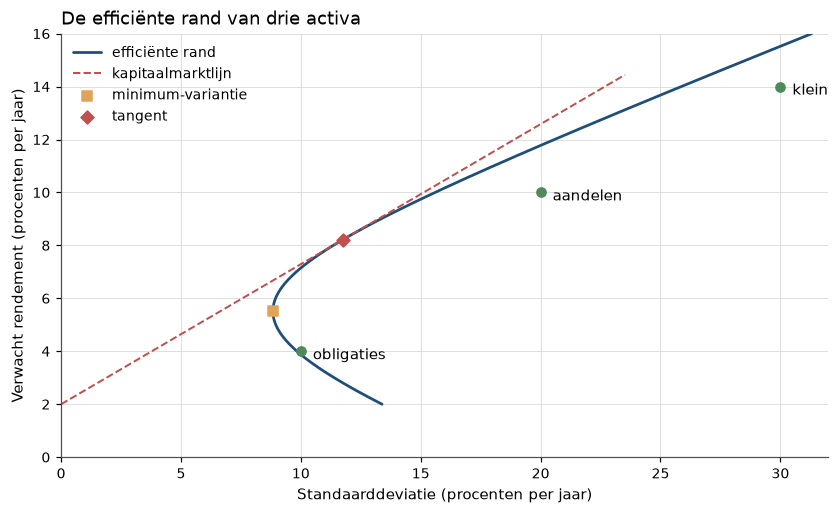

In [5]:
grid = np.linspace(0.02, 0.16, 400)
sigma_frontier = np.sqrt((A * grid**2 - 2 * B * grid + C) / D)
sigma_cml_end = 2 * sigma_tan                     # kapitaalmarktlijn tot 2x sigma_tan

fig, ax = plt.subplots()
ax.plot(sigma_frontier * 100, grid * 100, lw=1.8, label="efficiënte rand")
ax.plot([0, sigma_cml_end * 100],
        [rf * 100, (rf + sharpe_max * sigma_cml_end) * 100],
        ls="--", lw=1.3, color=hap.plotting.COLORS[1],
        label="kapitaalmarktlijn")
ax.scatter(sd * 100, mu * 100, zorder=3, color=hap.plotting.COLORS[2])
for name, s, m in zip(["aandelen", "klein", "obligaties"], sd, mu):
    ax.annotate(name, (s * 100 + 0.5, m * 100 - 0.3))
ax.scatter([sigma_mv * 100], [B / A * 100], marker="s", zorder=3,
           color=hap.plotting.COLORS[3], label="minimum-variantie")
ax.scatter([sigma_tan * 100], [mu_tan * 100],
           marker="D", zorder=3, color=hap.plotting.COLORS[1], label="tangent")
ax.set_xlim(0, 32)
ax.set_ylim(0, 16)
ax.set_xlabel("Standaarddeviatie (procenten per jaar)")
ax.set_ylabel("Verwacht rendement (procenten per jaar)")
ax.set_title("De efficiënte rand van drie activa")
ax.legend()
plt.show()

:::{figure} #cel-markowitz-frontier
:label: fig-markowitz-frontier
:width: 90%

De drie activa (punten), de efficiënte rand en de kapitaalmarktlijn vanaf de
risicovrije rente van 2%. Elk activum ligt rechts van de rand: er is telkens een
mengsel met hetzelfde verwachte rendement en minder risico. De
minimum-variantieportefeuille (vierkant) ligt met 8,83% links van het veiligste
activum. De tangentportefeuille (ruit) is het enige punt van de rand op de
kapitaalmarktlijn.
:::

De kapitaalmarktlijn ligt overal boven de rand, behalve in de
tangentportefeuille. Wie risico wil dragen, doet dat dus het best langs die lijn.

:::{prf:corollary} Separatiestelling van Tobin
:label: cor-markowitz-separatie

Met een risicovrij activum houdt elke belegger die alleen om $\mu_p$ en
$\sigma_p$ geeft een portefeuille van de vorm
$a\,\mathbf{w}_{\mathrm{tan}}$ plus $1-a$ in het risicovrije activum, met $a$
afhankelijk van zijn risicoaversie en $\mathbf{w}_{\mathrm{tan}}$ niet.
:::

:::{prf:proof}
Elke portefeuille die de belegger overweegt, ligt op een rechte door
$(0, R^{f})$. Bij een gegeven $\sigma_p$ is zijn verwachte rendement
$R^{f} + S(\mathbf{w})\sigma_p$, stijgend in $S$. Omdat hij alleen om $\mu_p$ en
$\sigma_p$ geeft (aanname 1) en onbeperkt kan lenen en uitlenen (aanname 4),
kiest hij bij elk $\sigma_p$ de $\mathbf{w}$ die $S$ maximeert, en dat is
[](#eq-markowitz-tangent). Alleen de dosis $a = \sigma_p/\sigma_{\mathrm{tan}}$
hangt van zijn voorkeuren af. $\square$
:::

Roy komt langs een andere weg bij dezelfde portefeuille uit. Zijn belegger wil de
kans klein maken dat zijn rendement onder een rampniveau $r_{\min}$ zakt, zonder
de verdeling te kennen. De ongelijkheid van Bienaymé-Tsjebysjev begrenst die
kans voor $\mu_p > r_{\min}$:

```{math}
:label: eq-markowitz-roy
\Pr\!\left(r_p < r_{\min}\right)
\le \Pr\!\left(\left|r_p - \mu_p\right| > \mu_p - r_{\min}\right)
\le \left(\frac{\mu_p - r_{\min}}{\sigma_p}\right)^{-2} .
```

In woorden: de kans op een ramp is hoogstens één gedeeld door het kwadraat van
het aantal standaarddeviaties tussen het verwachte rendement en de ramp. Die
grens minimaliseren is $(\mu_p - r_{\min})/\sigma_p$ maximaliseren, en dat is
[](#eq-markowitz-sharpe) met $r_{\min}$ in de rol van $R^{f}$. Een voorbeeld: de
tangentportefeuille uit het toy-voorbeeld (8,22%, standaarddeviatie 11,76%) en
een ramp van $r_{\min} = -20\%$ liggen 2,4 standaarddeviaties uit elkaar. De
grens is dan $1/2{,}4^2 = 17\%$, terwijl de kans onder normaliteit 0,8% is. De
belegger van Roy (*safety first*, veiligheid eerst) en die van Tobin kiezen dus dezelfde
portefeuille zodra $r_{\min} = R^{f}$.

### Wat het voorspelt: alleen covariantie wordt beloond

De bewering: in een grote portefeuille verdwijnt het idiosyncratische risico van
elk activum. Daarom is er geen reden om ervoor betaald te worden. Dat de markt
het ook niet doet, vraagt een evenwicht, en dat heeft Markowitz niet.

*Waarom zou dit waar zijn?* Een belegger verdeelt zijn geld gelijk over $N$
activa met elk variantie $\bar{v}$ en onderling covariantie $\bar{c}$. Koopt hij
er een activum bij, dan krijgt elk activum een kleiner gewicht. Het totaal van de
eigen varianties, $\bar{v}/N$, daalt naar nul. Het totaal van de covarianties,
$(1-1/N)\bar{c}$, stijgt licht naar $\bar{c}$.

```{math}
:label: eq-markowitz-1n
\Var\!\left(\frac{1}{N}\sum_{i=1}^{N} r_i\right)
= \frac{1}{N^2}\sum_{i} \Var(r_i)
+ \frac{1}{N^2}\sum_{i \neq j}\Cov(r_i,r_j)
= \frac{\bar{v}}{N} + \left(1 - \frac{1}{N}\right)\bar{c}
\ \xrightarrow[N\to\infty]{}\ \bar{c} .
```

In woorden: de eigen varianties verdwijnen, de gemiddelde covariantie blijft, en
die is de bodem van de diversificatie. Neem een maandelijkse standaarddeviatie
van 5,5% per aandeel en een gemiddelde correlatie van 0,25. De codecel rekent de
jaarlijkse standaarddeviatie uit voor portefeuilles van 1 tot 100 aandelen.

In [6]:
vbar = 0.055**2                 # variantie per aandeel, per maand
cbar = 0.25 * 0.055**2          # gemiddelde covariantie, per maand
n_grid = np.arange(1, 101)
sd_ann = np.sqrt(vbar / n_grid + (1 - 1 / n_grid) * cbar) * np.sqrt(12)

shown = [1, 5, 10, 30, 100]
pd.DataFrame(
    {"aantal aandelen": shown,
     "standaarddeviatie (% per jaar)": sd_ann[np.array(shown) - 1] * 100,
     "ondergrens (% per jaar)": np.sqrt(cbar * 12) * 100},
).round(2)

,aantal aandelen,standaarddeviatie (% per jaar),ondergrens (% per jaar)
0,1,19.05,9.53
1,5,12.05,9.53
2,10,10.86,9.53
3,30,9.99,9.53
4,100,9.67,9.53


Eén aandeel heeft 19,0% per jaar, een oneindig grote 1/N-portefeuille 9,5%, en
na dertig aandelen is het meeste al bereikt. In standaarddeviatie is de helft
weg te diversifiëren, in variantie driekwart, want de bodem is
$\bar{c}/\bar{v} = 0{,}25$ van de variantie van één aandeel. Bij een hogere
correlatie stijgt de bodem mee, bij correlatie nul verdwijnt hij.

De economische consequentie volgt uit een regressie. Splits het rendement van
activum $i$ in een deel dat met een grote gespreide portefeuille meebeweegt en
een rest: $r_i = k_i + \beta_{i,p} r_p + \varepsilon_i$ met
$\Cov(\varepsilon_i, r_p) = 0$. Dat is een definitie, geen aanname. De bijdrage
van $i$ aan de variantie van de portefeuille is
$\Cov(r_i, r_p) = \beta_{i,p}\Var(r_p)$, met $\beta_{i,p}$ de bèta van $i$
ten opzichte van $p$, rond 1 voor een gemiddeld aandeel. Daarin komt
$\Var(\varepsilon_i)$ niet voor.

Wie $\varepsilon_i$ draagt, draagt dus risico dat hij gratis had kunnen
wegdiversifiëren, en geen belegger die kan spreiden, wil hem daarvoor betalen,
zoals de intuïtie voorspelde.

### Waar het strandt: de schattingsfout in de invoer

De bewering: in de praktijk domineert de schattingsfout in $\boldsymbol{\mu}$
alles wat de theorie belooft. In [de lecture over rendementen](#00-01-rendementen)
bleek dat het gemiddelde rendement bij 20% standaarddeviatie over honderd
jaar een standaardfout van $20/\sqrt{100} = 2$ procentpunt heeft: de
standaardfout van 2%. Tweede momenten zijn wel scherp te meten, omdat een
variantie nauwkeuriger wordt met meer waarnemingen per jaar. Voor de
optimalisator is dat slecht gemeten gemiddelde om drie redenen fataal.

1. **De fout is groot.** Met $T$ waarnemingen en standaarddeviatie $\sigma$ per
   waarneming is $\SD(\hat\mu) = \sigma/\sqrt{T}$. Tien jaarwaarnemingen bij 20%
   geven $20/\sqrt{10} = 6{,}3$ procentpunt. De verschillen in verwachte rendementen
   tussen activa zijn een paar procentpunt, dus de rangorde van
   $\hat{\boldsymbol{\mu}}$ is vrijwel ruis.
2. **$\boldsymbol{\Sigma}^{-1}$ vergroot de ruis.** De gewichten zijn evenredig
   met $\boldsymbol{\Sigma}^{-1}\hat{\boldsymbol{\mu}}^{e}$. In het toy-voorbeeld
   zet de $-6{,}25$ in $\boldsymbol{\Sigma}^{-1}$ aandelen tegen kleine aandelen in,
   en hoe hoger hun correlatie, hoe groter dat getal in absolute waarde. Juist voor twee sterk
   gecorreleerde activa is het verschil tussen hun geschatte gemiddelden het
   slechtst bepaald. Een kleine verandering in één verwacht rendement kan de
   gewichten volledig omgooien {cite}`BestGrauer1991`.
3. **De fout is eenzijdig.** De geschatte maximale Sharpe-ratio is naar boven
   vertekend: $\E[\hat{S}^2_{\max}] \approx S^2_{\max} + N/T$. Elk geschat
   gemiddelde, gedeeld door zijn standaarddeviatie, heeft een steekproeffout met
   variantie ongeveer $1/T$, en de optimalisator telt $N$ van die kwadraten op
   {cite}`JobsonKorkie1980,JobsonKorkie1981`. Bij tien activa en $T = 120$ maandwaarnemingen is
   $N/T = 0{,}083$ per maand, vier keer de ware $S^2_{\max}$ van de simulatie
   hierna: $(0{,}50/\sqrt{12})^2 = 0{,}021$ per maand.

Hoe zwaar de drie soorten fouten wegen, is ook gemeten. In een van hun
rekenvoorbeelden kosten fouten in de gemiddelden ongeveer elf keer zoveel als
fouten in de varianties, en eenentwintig keer zoveel als fouten in de
covarianties {cite}`ChopraZiemba1993`.

```{warning}
De geschatte rand is geen belegbare uitkomst, want hij meet het rendement op
dezelfde waarnemingen waaruit $\hat{\boldsymbol{\mu}}$ en
$\hat{\boldsymbol{\Sigma}}$ komen. Vergelijk strategieën alleen buiten de
steekproef, met een standaardfout bij elke Sharpe-ratio.
```

```{admonition} Samengevat
:class: tip

- In het optimum is de covariantie van elk activum met de portefeuille een
  lineaire functie van zijn verwachte rendement, [](#eq-markowitz-foc). De
  minimum-variantieportefeuille $\boldsymbol{\Sigma}^{-1}\mathbf{1}/A$ gebruikt
  $\boldsymbol{\mu}$ niet.

- De kern: de efficiënte rand is een parabool in $(\mu_p, \sigma^2)$,
  [](#eq-markowitz-frontier), en elke portefeuille erop is een mengsel van twee
  vaste fondsen, {prf:ref}`thm-markowitz-tweefonds`.

- Met een risicovrij activum houdt iedereen dezelfde tangentportefeuille
  $\propto \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$, [](#eq-markowitz-tangent).
  Alleen de dosis verschilt. Een hogere $R^{f}$ schuift haar naar riskantere
  portefeuilles.

- In een grote portefeuille blijft alleen covariantie over, [](#eq-markowitz-1n).

- De fout in $\hat{\boldsymbol{\mu}}$ daalt met $\sqrt{T}$, de bias in de
  geschatte Sharpe-ratio groeit met $N/T$.

- De simulatie hierna vraagt: hoeveel van de beloofde Sharpe-ratio blijft over
  als de belegger $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$ moet schatten?
```

## Simulatie: de optimale portefeuille zonder kennis van $\boldsymbol{\mu}$

We bouwen een wereld met tien activa waarin we de ware momenten kennen, zodat de
optimale portefeuille en haar Sharpe-ratio bekend zijn. De vraag over
steekproeven: hoeveel daarvan levert een belegger die dezelfde portefeuille
bouwt uit $T$ maanden geschatte momenten?

De wereld lijkt op de tien industrieportefeuilles uit de replicatie: hoge
onderlinge correlatie, weinig verschil in premies. We werken direct met
overrendementen.

| parameter | waarde |
|---|---|
| aantal activa $N$ | 10 |
| premie | oplopend van 0,40% tot 0,80% per maand (4,8% tot 9,6% per jaar) |
| standaarddeviatie | oplopend van 4,5% tot 6,5% per maand |
| correlatie tussen elk paar | 0,60 |

De eerste cel bouwt die wereld en meet de ware Sharpe-ratio van twee
portefeuilles: het ware optimum (de tangentportefeuille bij de ware momenten) en
1/N. Omdat we de ware momenten kennen, meten we de Sharpe-ratio van elke
gewichtsvector exact, zonder steekproef.

In [7]:
n_assets = 10
mu_true = np.linspace(0.0040, 0.0080, n_assets)
sd_true = np.linspace(0.045, 0.065, n_assets)
corr_true = np.full((n_assets, n_assets), 0.60)
np.fill_diagonal(corr_true, 1.0)
Sigma_true = corr_true * np.outer(sd_true, sd_true)

chol = np.linalg.cholesky(Sigma_true)       # om gecorreleerde rendementen te trekken
w_star = np.linalg.solve(Sigma_true, mu_true)
w_star /= w_star.sum()                      # ware tangentportefeuille
w_naive = np.full(n_assets, 1 / n_assets)   # 1/N


def sharpe_true(w):
    """Annualised Sharpe ratio of weights w under the TRUE moments."""
    return np.sqrt(12) * (w @ mu_true) / np.sqrt(w @ Sigma_true @ w)


pd.DataFrame(
    {"Sharpe (per jaar)": [sharpe_true(w_star), sharpe_true(w_naive)]},
    index=["ware optimale portefeuille", "1/N"],
).round(4)

,Sharpe (per jaar)
ware optimale portefeuille,0.5035
1/N,0.4722


Het ware optimum haalt 0,50 per jaar, dicht bij de 0,529 van het
toy-voorbeeld. 1/N haalt 0,47. Dat kleine verschil is wat optimalisatie in deze
wereld hooguit kan opleveren.

Nu schat de belegger. Per steekproef trekken we $T$ maanden, schatten we
$\hat{\boldsymbol{\mu}}$ en $\hat{\boldsymbol{\Sigma}}$, vormen we de
portefeuille alsof die schattingen waar zijn, en meten we haar Sharpe-ratio onder
de ware momenten. Om te zien waar de schade vandaan komt, schatten we ook telkens
maar één van de twee.

In [8]:
def one_sample(T):
    """Draw T months from the true world; return the sample mean and covariance."""
    sample = rng.standard_normal((T, n_assets)) @ chol.T + mu_true
    return sample.mean(axis=0), np.cov(sample, rowvar=False)


def tangency(mu_vec, Sigma_mat):
    """Fully invested maximum-Sharpe weights, Sigma^{-1} mu scaled to sum to one."""
    w = np.linalg.solve(Sigma_mat, mu_vec)
    return w / w.sum()


n_sim = 2000
records = []
for T in [60, 120, 240, 600]:
    both, cov_only, mean_only = [], [], []
    for _ in range(n_sim):
        mu_hat, Sigma_hat = one_sample(T)                                  # trekken en schatten
        both.append(sharpe_true(tangency(mu_hat, Sigma_hat)))             # optimaliseren
        cov_only.append(sharpe_true(tangency(mu_true, Sigma_hat)))
        mean_only.append(sharpe_true(tangency(mu_hat, Sigma_true)))
    records.append({
        "T (maanden)": T,
        "gemiddelden en covarianties geschat": np.median(both),
        "alleen covarianties geschat": np.median(cov_only),
        "alleen gemiddelden geschat": np.median(mean_only),
        "1/N": sharpe_true(w_naive),
        "ware optimum": sharpe_true(w_star),
    })

pd.DataFrame(records).set_index("T (maanden)").round(4)

,gemiddelden en covarianties geschat,alleen covarianties geschat,alleen gemiddelden geschat,1/N,ware optimum
T (maanden),,,,,
60,0.1606,0.4661,0.1721,0.4722,0.5035
120,0.2308,0.4849,0.2366,0.4722,0.5035
240,0.3014,0.4949,0.3065,0.4722,0.5035
600,0.3877,0.4999,0.3917,0.4722,0.5035


Schatten kost veel meer dan optimaliseren kan opleveren. De mean-variance-portefeuille
uit geschatte momenten haalt een mediane Sharpe-ratio van 0,16 bij vijf jaar data
en 0,39 bij vijftig jaar, en blijft over het hele bereik onder 1/N.

De kolommen met één geschatte invoer laten zien waar de schade zit. Wie
$\boldsymbol{\mu}$ kent en $\boldsymbol{\Sigma}$ schat, verliest bijna niets. Wie
$\boldsymbol{\Sigma}$ kent en $\boldsymbol{\mu}$ schat, verliest bijna alles.
De gemiddelden zijn de zwakke schakel, net als bij
{cite:t}`ChopraZiemba1993`.

De figuur vergelijkt voor $T = 120$ wat de optimalisator *in de steekproef*
belooft met wat hij *buiten de steekproef* levert. Let op de afstand tussen de
twee verdelingen en op de ligging van de zwarte lijn.

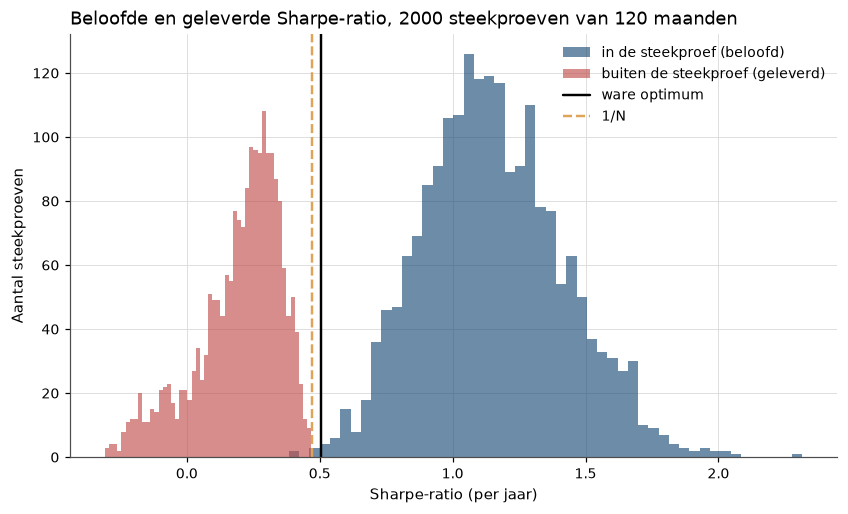

In [9]:
sr_oos, sr_ins = [], []
for _ in range(n_sim):
    mu_hat, Sigma_hat = one_sample(120)
    sr_oos.append(sharpe_true(tangency(mu_hat, Sigma_hat)))                 # geleverd
    sr_ins.append(np.sqrt(12 * mu_hat @ np.linalg.solve(Sigma_hat, mu_hat)))  # beloofd

fig, ax = plt.subplots()
ax.hist(sr_ins, bins=50, alpha=0.65, label="in de steekproef (beloofd)")
ax.hist(sr_oos, bins=50, alpha=0.65, label="buiten de steekproef (geleverd)")
ax.axvline(sharpe_true(w_star), color="black", lw=1.6,
           label="ware optimum")
ax.axvline(sharpe_true(w_naive), color=hap.plotting.COLORS[3], lw=1.6,
           ls="--", label="1/N")
ax.set_xlabel("Sharpe-ratio (per jaar)")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("Beloofde en geleverde Sharpe-ratio, 2000 steekproeven van 120 maanden")
ax.legend()
plt.show()

:::{figure} #cel-markowitz-simulatie
:label: fig-markowitz-simulatie
:width: 90%

Twee verdelingen uit dezelfde 2000 steekproeven van tien jaar. De rechter is wat
de optimalisator *belooft*: de Sharpe-ratio in de steekproef, ruim boven het ware
optimum. De linker is wat hij *levert*: dezelfde gewichten onder de ware
momenten, altijd onder het ware optimum en in deze figuur ook onder 1/N. De afstand is
bias: de optimalisator kiest de gewichten juist waar de schattingsfout het
gemiddelde toevallig hoog maakte.
:::

Elk extra activum is een extra kans op een gemiddelde dat toevallig hoog
uitvalt. Wie honderd activa optimaliseert op tien jaar data ($N/T$ tien
keer zo groot als hier), rapporteert een Sharpe-ratio die vrijwel volledig uit
schattingsfout bestaat.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** DeMiguel, Garlappi en Uppal (hierna DGU), *Optimal Versus Naive
Diversification: How Inefficient Is the 1/N Portfolio Strategy?*, Review of
Financial Studies 2009 {cite}`DeMiguelGarlappiUppal2009`.

**Wat.** Tabel 3: de Sharpe-ratio buiten de steekproef van 1/N tegenover de
mean-variance-portefeuille, geschat op een rollend venster van $M = 120$
maanden. Geen van hun veertien modellen verslaat 1/N consequent.

**Data hier.** De tien industrieportefeuilles en de 25 size/BM-portefeuilles
(gesorteerd op beurswaarde en boek-marktwaarde) van French, als overrendement,
vanaf juli 1963.

**Verschil met het origineel.** DGU stoppen in november 2004, wij ruim twintig
jaar later, en we nemen drie van hun veertien schatters over: 1/N,
minimum-variantie en mean-variance. Hun FF-vierfactordataset heeft 24 reeksen van de French-website, vanaf juli
1963. Die dataset ligt het dichtst bij onze 25 portefeuilles.
Voor de industrieën hebben we hun getallen niet.

**Verwachte afwijking.** Het niveau wijkt af, de ordening niet: mean-variance
in de steekproef boven 1/N, erbuiten eronder, en het gat tussen belofte en
levering groter bij grotere $N$. Met 637 maanden buiten de steekproef is de
standaardfout van een maandelijkse Sharpe-ratio ongeveer 0,04, dus alleen teken
en ordening zijn informatief.
```

De eerste cel laadt beide panelen en trekt de risicovrije rente af.

In [10]:
rf_monthly = hap_data.market_monthly()["RF"]    # andere naam dan de rf = 0,02 uit de theorie


def excess_panel(name, start="1963-07"):
    """French portfolio returns in excess of the risk-free rate."""
    raw = hap_data.french(name, "monthly").loc[start:]
    return raw.sub(rf_monthly, axis=0).dropna()


industry = excess_panel("10_Industry_Portfolios")   # value-weighted, maandelijks
size_bm = excess_panel("25_Portfolios_5x5")          # 25 size/BM-portefeuilles

pd.DataFrame(
    {"N": [industry.shape[1], size_bm.shape[1]],
     "maanden": [len(industry), len(size_bm)],
     "start": [industry.index[0].strftime("%Y-%m"), size_bm.index[0].strftime("%Y-%m")],
     "eind": [industry.index[-1].strftime("%Y-%m"), size_bm.index[-1].strftime("%Y-%m")]},
    index=["10 industrieën", "25 size/BM"],
)

,N,maanden,start,eind
10 industrieën,10,757,1963-07,2026-07
25 size/BM,25,757,1963-07,2026-07


Beide panelen hebben 757 maanden, van juli 1963 tot juli 2026.

Het recept van DGU: in elke maand $t \ge M$ schatten we $\hat{\boldsymbol{\mu}}$
en $\hat{\boldsymbol{\Sigma}}$ uit de voorgaande $M = 120$ maanden, vormen we de
gewichten en boeken we het rendement van maand $t$. Er komt geen informatie uit
de toekomst in de gewichten, en de functie bewaart de mean-variance-gewichten.

In [11]:
def rolling_oos(panel, window=120):
    """Out-of-sample returns of 1/N, mean-variance and minimum variance,
    plus the mean-variance weights of every month."""
    values = panel.to_numpy()
    n = panel.shape[1]
    ones = np.ones(n)
    returns = {"1/N": [], "mean-variance": [], "minimum-variantie": []}
    weights_mv = []

    for t in range(window, len(values)):
        past = values[t - window:t]                 # alleen maanden vóór t
        mu_hat = past.mean(axis=0)
        Sigma_hat = np.cov(past, rowvar=False)

        w_meanvar = np.linalg.solve(Sigma_hat, mu_hat)
        w_meanvar = w_meanvar / w_meanvar.sum()
        w_minvar = np.linalg.solve(Sigma_hat, ones)
        w_minvar = w_minvar / w_minvar.sum()

        returns["1/N"].append(values[t] @ ones / n)
        returns["mean-variance"].append(values[t] @ w_meanvar)
        returns["minimum-variantie"].append(values[t] @ w_minvar)
        weights_mv.append(w_meanvar)

    return pd.DataFrame(returns, index=panel.index[window:]), np.array(weights_mv)


oos_industry, weights_industry = rolling_oos(industry)
oos_size_bm, weights_size_bm = rolling_oos(size_bm)
pd.DataFrame(
    {"maanden buiten de steekproef": [len(oos_industry), len(oos_size_bm)],
     "eerste maand": [oos_industry.index[0].strftime("%Y-%m"),
                      oos_size_bm.index[0].strftime("%Y-%m")]},
    index=["10 industrieën", "25 size/BM"],
)

,maanden buiten de steekproef,eerste maand
10 industrieën,637,1973-07
25 size/BM,637,1973-07


Na het eerste venster blijven 637 maanden buiten de steekproef over. De volgende
cel vat de drie reeksen samen, met de standaardfout $1/\sqrt{637} = 0{,}04$ van
de Sharpe-ratio erbij (bij een kleine Sharpe-ratio is die ongeveer $1/\sqrt{T}$).

In [12]:
def sharpe_table(oos):
    """Mean, standard deviation and Sharpe ratio of each out-of-sample strategy."""
    summary = hap.summary_stats(oos, "monthly")
    return pd.DataFrame({
        "gemiddelde (% per maand)": summary["mean"] * 100,
        "standaarddeviatie (% per maand)": summary["std"] * 100,
        "Sharpe-ratio (per maand)": summary["mean"] / summary["std"],
        "SE van de Sharpe-ratio": 1 / np.sqrt(summary["nobs"].astype(float)),
    })


table = pd.concat({"10 industrieën": sharpe_table(oos_industry),
                   "25 size/BM": sharpe_table(oos_size_bm)})
table.astype(float).round(4)

gemiddelde (% per maand)  \
10 industrieën 1/N                                  0.6872   
               mean-variance                        1.1674   
               minimum-variantie                    0.6002   
25 size/BM     1/N                                  0.8329   
               mean-variance                        8.1558   
               minimum-variantie                    0.9435   

                                  standaarddeviatie (% per maand)  \
10 industrieën 1/N                                         4.3465   
               mean-variance                              14.4614   
               minimum-variantie                           3.6321   
25 size/BM     1/N                                         5.2375   
               mean-variance                              78.6441   
               minimum-variantie                           3.9425   

                                  Sharpe-ratio (per maand)  \
10 industrieën 1/N                                  0.1581   
               mean-variance                        0.0807   
               minimum-variantie                    0.1653   
25 size/BM     1/N                                  0.1590   
               mean-variance                        0.1037   
               minimum-variantie                    0.2393   

                                  SE van de Sharpe-ratio  
10 industrieën 1/N                                0.0396  
               mean-variance                      0.0396  
               minimum-variantie                  0.0396  
25 size/BM     1/N                                0.0396  
               mean-variance                      0.0396  
               minimum-variantie                  0.0396

In beide datasets verliest mean-variance van 1/N, en doet minimum-variantie het
het best. Mean-variance beweegt ook veel wilder, met bij de industrieën ruim drie keer de
standaarddeviatie van 1/N. De laatste cel zet
onze Sharpe-ratio's naast de FF-vierfactorrij uit tabel 3 van DGU, met de
Sharpe-ratio in de steekproef erbij.

In [13]:
def in_sample_sharpe(panel):
    """Monthly maximum Sharpe ratio attainable with full-sample moments."""
    mu_hat = panel.mean().to_numpy()
    Sigma_hat = panel.cov().to_numpy()
    return float(np.sqrt(mu_hat @ np.linalg.solve(Sigma_hat, mu_hat)))


sharpe_oos = table["Sharpe-ratio (per maand)"].unstack()
comparison = pd.DataFrame(
    {"1/N": [sharpe_oos.loc["10 industrieën", "1/N"], 0.1753,
             sharpe_oos.loc["25 size/BM", "1/N"]],
     "mean-variance in de steekproef": [in_sample_sharpe(industry), 0.5364,
                                        in_sample_sharpe(size_bm)],
     "mean-variance buiten de steekproef": [sharpe_oos.loc["10 industrieën", "mean-variance"],
                                            -0.0031,
                                            sharpe_oos.loc["25 size/BM", "mean-variance"]]},
    index=["hier: 10 industrieën (N = 10)", "origineel: FF-vierfactor (N = 24)",
           "hier: 25 size/BM (N = 25)"],
)                                                    # origineel: DGU (2009), tabel 3
comparison["verschil met 1/N buiten"] = (comparison["mean-variance buiten de steekproef"]
                                         - comparison["1/N"])
comparison["gat: in minus buiten"] = (comparison["mean-variance in de steekproef"]
                                      - comparison["mean-variance buiten de steekproef"])
comparison.round(4)

,1/N,mean-variance in de steekproef,mean-variance buiten de steekproef,verschil met 1/N buiten,gat: in minus buiten
hier: 10 industrieën (N = 10),0.1581,0.1848,0.0807,-0.0774,0.1040
origineel: FF-vierfactor (N = 24),0.1753,0.5364,-0.0031,-0.1784,0.5395
hier: 25 size/BM (N = 25),0.1590,0.4022,0.1037,-0.0553,0.2985


**Geslaagd.** De ordening is dezelfde als bij DGU en als het replicatieblok
voorspelde. In de steekproef belooft mean-variance meer dan 1/N (bij de
industrieën net, bij de 25 portefeuilles ruim), erbuiten levert zij minder. Het
gat tussen belofte en levering (laatste kolom) groeit met $N$, van 0,10 naar
0,30, en is bij DGU nog groter. Hun niveau buiten de steekproef is negatief en
het onze positief, maar het blok liet het niveau open.

Eén voorbehoud hoort erbij. Onze eigen verschillen met 1/N (voorlaatste kolom)
zijn kleiner dan twee keer de standaardfout van één Sharpe-ratio, terwijl de
DGU-rij daar wel boven ligt. Dat is een ruwe
drempel: de standaardfout van een verschil hangt af van hoe sterk de twee
strategieën samen bewegen. De replicatie stelt een consistent teken vast over
twee datasets, geen significant verschil in één.

De winnaar is dus niet 1/N maar de minimum-variantieportefeuille, in de
samenvattende tabel de hoogste Sharpe-ratio in beide datasets. Haar gewichten
$\boldsymbol{\Sigma}^{-1}\mathbf{1}/A$ gebruiken $\hat{\boldsymbol{\mu}}$ niet.
Wie deze maandcijfers met de simulatie vergelijkt, vermenigvuldigt ze met
$\sqrt{12}$.

De figuur toont de cumulatieve overrendementen van de drie strategieën. Let op
hoe onrustig de mean-variance-lijn is.

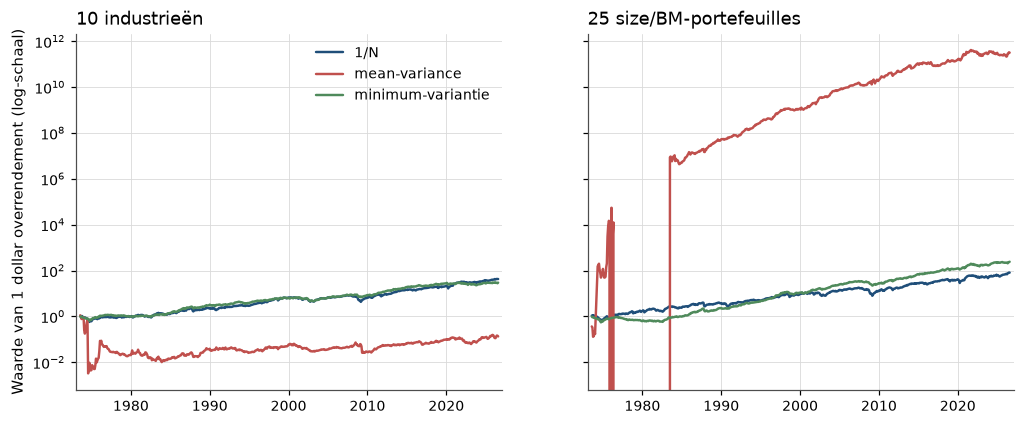

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (title, frame) in zip(axes, [("10 industrieën", oos_industry),
                                     ("25 size/BM-portefeuilles", oos_size_bm)]):
    for column in frame.columns:
        ax.plot(frame.index, (1 + frame[column]).cumprod(), label=column)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Jaar")
    hap.plotting.timeline_axis(ax)
axes[0].set_ylabel("Waarde van 1 dollar overrendement (log-schaal)")
axes[0].legend()
plt.show()

:::{figure} #cel-markowitz-cumulatief
:label: fig-markowitz-cumulatief
:width: 100%

Cumulatief overrendement van de drie strategieën, gefinancierd tegen de
risicovrije rente, met een rollend venster van 120 maanden. De
mean-variance-portefeuille is slechter en onrustiger: haar gewichten springen
elke maand mee met tien jaar geschatte gemiddelden.
:::

Waarom is mean-variance zo slecht? De volgende cel meet de posities die de
optimalisator in elk venster inneemt, uit de bewaarde gewichten.

In [15]:
position_stats = {}
for name, weights in [("10 industrieën", weights_industry),
                      ("25 size/BM", weights_size_bm)]:
    gross_position = np.abs(weights).sum(axis=1)                  # som van |w| per maand
    turnover = np.abs(np.diff(weights, axis=0)).sum(axis=1)       # omzet per maand
    position_stats[name] = {
        "grootste positieve gewicht": weights.max(),
        "grootste negatieve gewicht": weights.min(),
        "gemiddelde brutopositie (som van |w|)": gross_position.mean(),
        "gemiddelde omzet per maand": turnover.mean(),
    }

pd.DataFrame(position_stats).T.round(3)

,grootste positieve gewicht,grootste negatieve gewicht,gemiddelde brutopositie (som van |w|),gemiddelde omzet per maand
10 industrieën,21.030,-21.219,7.451,2.014
25 size/BM,1158.125,-699.084,72.256,71.678


De optimalisator neemt enorme posities: gewichten van meer dan twintig maal het
vermogen bij de industrieën, en een veelvoud daarvan bij de 25 portefeuilles. De
brutopositie is de som van de absolute gewichten, de omzet de som van de
absolute gewichtsveranderingen per maand. De optimalisator behandelt een klein verschil in geschat
gemiddelde tussen twee sterk gecorreleerde portefeuilles als een bijna
risicoloze arbitrage. Dat verschil is ruis: hier zit hefboom op een
schattingsfout, het mechanisme van punt 2 in de theorie.

```{tip}
De bekende oplossingen houden de optimalisator weg van $\hat{\boldsymbol{\mu}}$:
negatieve gewichten verbieden, posities begrenzen, of $\hat{\boldsymbol{\mu}}$
krimpen naar één gemeenschappelijk gemiddelde (oefening 3). Wie niets aanneemt over
verwachte rendementen, komt uit bij 1/N of de minimum-variantieportefeuille.
```

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Het is nooit weerlegd, want het is een stelling,
geen hypothese. Het risico van een belegging is haar covariantie met de rest van
de portefeuille. Een mengsel kan veiliger zijn dan het veiligste activum, twee
fondsen bedienen iedere belegger, ook de voorzichtige van Roy, en
idiosyncratisch risico is gratis weg te diversifiëren. De separatiestelling geeft indexbeleggen bovendien een
theoretische grond naast het kostenargument.

**Waar het breekt.** Niet in de wiskunde maar in de invoer. De replicatie laat
zien dat de mean-variance-portefeuille, geschat op tien jaar maanddata, een
lagere Sharpe-ratio haalt dan 1/N: bij de tien industrieën 0,081 tegen 0,158 per
maand, terwijl de optimalisatie in de steekproef 0,185 beloofde. Volgens DGU
zijn bij $N = 25$ meer dan drieduizend maanden data nodig, ruim 250 jaar, voordat
optimaliseren loont {cite}`DeMiguelGarlappiUppal2009`. De oorzaak is de
schattingsfout in de gemiddelden: $\boldsymbol{\Sigma}$ is goed te schatten,
$\boldsymbol{\mu}$ niet.

**Risico of vergissing?** Waarom verliest mean-variance? De Chicago-lezing: prijzen zijn
juist, dus verwachte rendementen verschillen weinig en alleen door risico. Wie op geschatte gemiddelden jaagt, jaagt op ruis. De Yale-lezing: de
verschillen zijn echt en groot (waarde, momentum, kleine aandelen), maar prijzen
zitten soms ernaast en tien jaar gemiddelden tonen dat niet. Dan faalt de
*schatter*, niet het idee. Alleen een voorspeller die buiten de steekproef werkt,
zou de twee scheiden ([](#04-20-voorspelbaarheid)).
Santa-Clara ([](#00-00-setup)) verloor naar eigen zeggen geld als hij dacht
iets te weten wat de prijs niet wist. De mean-variance-portefeuille maakt die
fout systematisch: zij wedt dat haar geschatte gemiddelden meer weten dan de
prijs.

**Wat er daarna kwam.** Markowitz beschrijft wat één belegger zou moeten doen,
bij gegeven $\boldsymbol{\mu}$. Wat de markt werkelijk opleverde, was in 1959
nog niet gemeten. Die meting kwam er in 1964 met de CRSP-tape: zie
[](#02-05-crsp-tape).

## Oefeningen

:::{exercise}
:label: ex-markowitz-instap

**Instap: het toy-voorbeeld zonder correlatie.** Neem het toy-voorbeeld, maar
laat de correlatie tussen aandelen en kleine aandelen nul zijn in plaats van 1/3.

1. Bereken de gewichten en de standaarddeviatie van de
   minimum-variantieportefeuille met de hand.
2. Stijgt of daalt die standaarddeviatie ten opzichte van 8,83%, en waarom
   krijgen kleine aandelen meer gewicht?
:::

:::{solution} ex-markowitz-instap
:class: dropdown

**(1)** Nu is $\boldsymbol{\Sigma}$ diagonaal, dus
$\boldsymbol{\Sigma}^{-1}\mathbf{1} = (1/0{,}04;\; 1/0{,}09;\; 1/0{,}01)'
= (25;\; 11{,}11;\; 100)'$. Maal 9 geeft $(225;\; 100;\; 900)$, met som 1225, dus
$\mathbf{w}_{\mathrm{mv}} = (9/49;\; 4/49;\; 36/49)' = (0{,}1837;\; 0{,}0816;\;
0{,}7347)'$. De covariantie van elk activum met de portefeuille is weer gelijk:
$0{,}04 \cdot 9/49 = 0{,}09 \cdot 4/49 = 0{,}01 \cdot 36/49 = 0{,}36/49$. Dus
$\sigma^2_{\mathrm{mv}} = 0{,}36/49$ en $\sigma_{\mathrm{mv}} = 0{,}6/7 = 8{,}57\%$.

In [16]:
Sigma_uncorr = np.diag(sd**2)                     # correlatie tussen de aandelen op nul
Sinv_1_uncorr = np.linalg.solve(Sigma_uncorr, ones)
w_mv_uncorr = Sinv_1_uncorr / Sinv_1_uncorr.sum()
sigma_mv_uncorr = np.sqrt(w_mv_uncorr @ Sigma_uncorr @ w_mv_uncorr)

pd.DataFrame(
    {"met de hand": [0.1837, 0.0816, 0.7347, 0.0857],
     "code": [*w_mv_uncorr, sigma_mv_uncorr]},
    index=["gewicht aandelen", "gewicht kleine aandelen", "gewicht obligaties",
           "standaarddeviatie"],
).round(4)

,met de hand,code
gewicht aandelen,0.1837,0.1837
gewicht kleine aandelen,0.0816,0.0816
gewicht obligaties,0.7347,0.7347
standaarddeviatie,0.0857,0.0857


**(2)** De standaarddeviatie daalt van 8,83% naar 8,57%. Kleine aandelen bewegen niet
meer met aandelen mee, voegen dus echte diversificatie toe en krijgen 8,2% in
plaats van 4,9%.
Wat dit leert: minder covariantie maakt de minimum-variantieportefeuille
veiliger, zonder dat een enkel activum minder riskant wordt.
:::

:::{exercise}
:label: ex-markowitz-1

**De zero-beta-portefeuille.** Werk met het toy-voorbeeld en de getallen uit de
theorie ($A = 128{,}125$, $B = 7{,}0625$, $C = 0{,}51125$, $D = 15{,}625$).

1. Leid uit [](#eq-markowitz-foc) af dat de covariantie tussen twee
   portefeuilles op de rand met verwachte rendementen $\mu_1$ en $\mu_2$ gelijk is
   aan $\left(A\mu_1\mu_2 - B(\mu_1+\mu_2) + C\right)/D$.
2. Bepaal daaruit het verwachte rendement $\mu_z$ van de portefeuille op de
   rand die *ongecorreleerd* is met de tangentportefeuille
   ($\mu_{\mathrm{tan}} = 0{,}0822\overline{2}$). Reken het getal met de hand uit
   en controleer het in code.
3. Dat getal heet het zero-beta-rendement. Vergelijk het met de risicovrije rente
   van 2% waarmee de tangentportefeuille werd bepaald. Wat valt op, en waarom is
   dat geen toeval?
:::

:::{solution} ex-markowitz-1
:class: dropdown

**(1)** Uit [](#eq-markowitz-foc) is $\boldsymbol{\Sigma}\mathbf{w}_2 =
\lambda_2\boldsymbol{\mu} + \delta_2\mathbf{1}$, dus
$\Cov(r_1, r_2) = \mathbf{w}_1'\boldsymbol{\Sigma}\mathbf{w}_2
= \lambda_2\mu_1 + \delta_2$, want $\mathbf{w}_1'\boldsymbol{\mu} = \mu_1$ en
$\mathbf{w}_1'\mathbf{1}=1$. Invullen van
$\lambda_2 = (A\mu_2 - B)/D$ en $\delta_2 = (C - B\mu_2)/D$ geeft
$\left(A\mu_1\mu_2 - B\mu_1 - B\mu_2 + C\right)/D$, symmetrisch in $\mu_1$ en
$\mu_2$. Voor $\mu_1 = \mu_2$ is dit [](#eq-markowitz-frontier).

**(2)** Nul stellen en oplossen naar $\mu_z$ geeft
$\mu_z = (B\mu_{\mathrm{tan}} - C)/(A\mu_{\mathrm{tan}} - B)$. Met
$\mu_{\mathrm{tan}} = 37/450 = 0{,}0822\overline{2}$ is de teller
$7{,}0625 \cdot 0{,}0822\overline{2} - 0{,}51125 = 0{,}580694 - 0{,}51125
= 0{,}069444$ en de noemer
$128{,}125 \cdot 0{,}0822\overline{2} - 7{,}0625 = 10{,}534722 - 7{,}0625
= 3{,}472222$, dus $\mu_z = 0{,}0200$.

In [17]:
mu_z = (B * mu_tan - C) / (A * mu_tan - B)
w_z = (Sinv_mu * (A * mu_z - B) + Sinv_1 * (C - B * mu_z)) / D   # w = g + mu_z h

pd.DataFrame(
    {"waarde": [mu_tan, mu_z, float(w_z @ Sigma @ w_tan)]},
    index=["mu van de tangentportefeuille", "zero-beta rendement",
           "covariantie met de tangentportefeuille"],
).round(8)

,waarde
mu van de tangentportefeuille,0.082222
zero-beta rendement,0.020000
covariantie met de tangentportefeuille,-0.000000


**(3)** Het zero-beta-rendement is exact 2%, gelijk aan de risicovrije rente
waarmee we de tangentportefeuille bepaalden. Dat is geen toeval. Uit
$\mathbf{w}_{\mathrm{tan}} \propto \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} -
R^{f}\mathbf{1})$ volgt voor elke portefeuille $\mathbf{v}$ met
$\mathbf{v}'\mathbf{1} = 1$ dat
$\Cov(r_v, r_{\mathrm{tan}}) \propto \mathbf{v}'(\boldsymbol{\mu} - R^{f}\mathbf{1})
= \mu_v - R^{f}$. Nulcovariantie betekent dus $\mu_v = R^{f}$. Dit is de kern van
{cite:t}`Black1972`: ook zonder risicovrij activum bestaat er een portefeuille
die de rol van $R^{f}$ speelt. Wat dit leert: de risicovrije rente is in de
meetkunde van de rand het rendement van de portefeuille die niet met de
tangentportefeuille meebeweegt.
:::

:::{exercise}
:label: ex-markowitz-3

**De replicatie uitbreiden: krimpen.** Herhaal de rollende analyse buiten de
steekproef op de 25 size/BM-portefeuilles, maar krimp $\hat{\boldsymbol{\mu}}$ in
elk venster naar het gemiddelde over alle portefeuilles:
$\tilde{\boldsymbol{\mu}} = \phi\,\hat{\boldsymbol{\mu}} +
(1-\phi)\,\bar{\hat\mu}\,\mathbf{1}$, met $\phi \in \{0; 0{,}25; 0{,}5; 0{,}75; 1\}$.

1. Bereken voor elke $\phi$ de Sharpe-ratio buiten de steekproef, de gemiddelde
   brutopositie en de gemiddelde omzet.
2. Vergelijk $\phi = 0$ met $\phi = 1$. Welke portefeuille is het bij $\phi = 0$?
3. Zit het probleem bij de optimalisatie of bij de invoer?
:::

:::{solution} ex-markowitz-3
:class: dropdown

De functie herhaalt de rollende analyse, met in elk venster de gekrompen
gemiddelden in plaats van $\hat{\boldsymbol{\mu}}$.

In [18]:
def shrunk_oos(panel, phi, window=120):
    """Rolling OOS mean-variance with the mean vector shrunk towards its average."""
    values = panel.to_numpy()
    rets, paths = [], []
    for t in range(window, len(values)):
        past = values[t - window:t]
        mu_hat = past.mean(axis=0)
        mu_tilde = phi * mu_hat + (1 - phi) * mu_hat.mean()
        w = np.linalg.solve(np.cov(past, rowvar=False), mu_tilde)
        w = w / w.sum()
        rets.append(float(values[t] @ w))
        paths.append(w)
    rets, paths = np.array(rets), np.array(paths)
    return {
        "Sharpe-ratio (per maand)": rets.mean() / rets.std(ddof=1),
        "brutopositie": np.abs(paths).sum(axis=1).mean(),
        "omzet": np.abs(np.diff(paths, axis=0)).sum(axis=1).mean(),
    }


pd.DataFrame(
    {phi: shrunk_oos(size_bm, phi) for phi in [0.0, 0.25, 0.5, 0.75, 1.0]}
).T.rename_axis("phi").round(3)

,Sharpe-ratio (per maand),brutopositie,omzet
phi,,,
0.00,0.239,7.565,0.729
0.25,0.054,29.585,34.738
0.50,0.000,102.469,151.495
0.75,0.031,180.237,277.413
1.00,0.104,72.256,71.678


**(1) en (2)** $\phi = 0$ wint met afstand: een Sharpe-ratio van 0,239 tegen
0,104 bij $\phi = 1$, en een brutopositie van 7,6 in plaats van 72. Bij
$\phi = 0$ is $\tilde{\boldsymbol{\mu}}$ evenredig met $\mathbf{1}$, dus is de
portefeuille exact de minimum-variantieportefeuille
$\boldsymbol{\Sigma}^{-1}\mathbf{1}/A$. De tussenwaarden doen het slechter,
omdat $\mathbf{1}'\boldsymbol{\Sigma}^{-1}\tilde{\boldsymbol{\mu}}$ soms dicht
bij nul komt en de normalisatie dan explodeert.

**(3)** De optimalisatie is niet het probleem. Hetzelfde kwadratische programma,
met $\hat{\boldsymbol{\mu}}$ volledig weggekrompen, levert het beste resultaat
van deze lecture. Wat dit leert: het nuttigste wat een belegger over
$\hat{\boldsymbol{\mu}}$ kan weten, is hoeveel hij hem *niet* moet geloven.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->